### グラフの表示

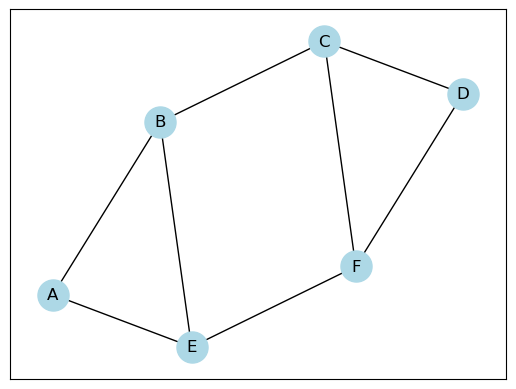

In [16]:
### リスト1 ###

import networkx as nx
import matplotlib.pyplot as plt

# グラフオブジェクトの作成
G = nx.Graph()

# エッジの追加
G.add_edge('A', 'B')
G.add_edge('A', 'E')
G.add_edge('B', 'C')
G.add_edge('B', 'E')
G.add_edge('C', 'D')
G.add_edge('C', 'F')
G.add_edge('D', 'F')
G.add_edge('E', 'F')


# レイアウトの設定（ノードの配置）
pos = nx.spring_layout(G)

# グラフの描画
# ノードとエッジを描画
nx.draw_networkx(G, pos, with_labels=True, node_color='lightblue', node_size=500)

# 表示
#plt.axis('off')
plt.show()

### 辺に重みの付いたグラフ

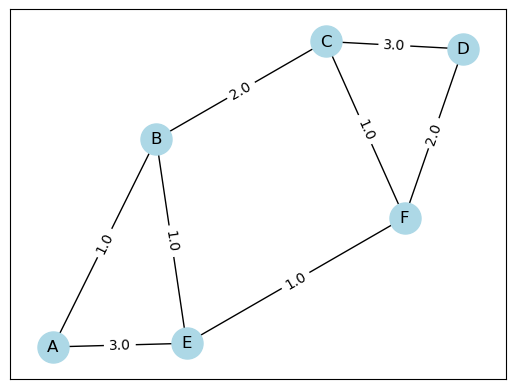

In [27]:
### リスト2 ###

import networkx as nx
import matplotlib.pyplot as plt

# グラフオブジェクトの作成
G = nx.Graph()

# エッジ（重み付き）の追加
G.add_edge('A', 'B', weight=1.0)
G.add_edge('A', 'E', weight=3.0)
G.add_edge('B', 'C', weight=2.0)
G.add_edge('B', 'E', weight=1.0)
G.add_edge('C', 'D', weight=3.0)
G.add_edge('C', 'F', weight=1.0)
G.add_edge('D', 'F', weight=2.0)
G.add_edge('E', 'F', weight=1.0)


# レイアウトの設定（ノードの配置）
pos = nx.spring_layout(G)

# グラフの描画
# ノードとエッジを描画
nx.draw_networkx(G, pos, with_labels=True, node_color='lightblue', node_size=500)

# エッジの重みラベルを描画
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# 表示
#plt.axis('off')
plt.show()

### 有向グラフの作成

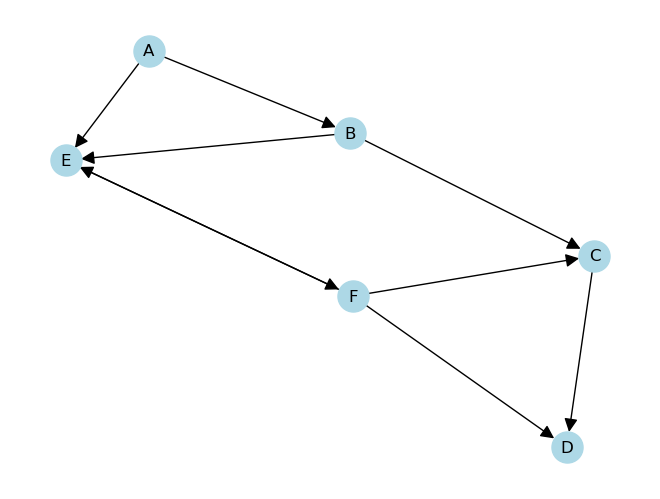

In [91]:
### リスト3 ###

import networkx as nx
import matplotlib.pyplot as plt

# 有向グラフの作成
G = nx.DiGraph()

# エッジ（リンク）の追加 (ノードA -> ノードB)
edges = [('A', 'B'), ('A', 'E'), 
         ('B', 'C'), ('B', 'E'), 
         ('C', 'D'), 
         ('E', 'F'), 
         ('F', 'C'), ('F', 'D'), ('F', 'E')]
G.add_edges_from(edges)

# 表示
pos = nx.spring_layout(G)
#nx.draw(G, pos, with_labels=True, node_size=500, node_color='lightblue', font_size=15, arrowsize=20)
nx.draw(G, pos, with_labels=True, node_size=500, node_color='lightblue', arrowsize=20)
plt.show()

### 参考：より複雑なグラフ

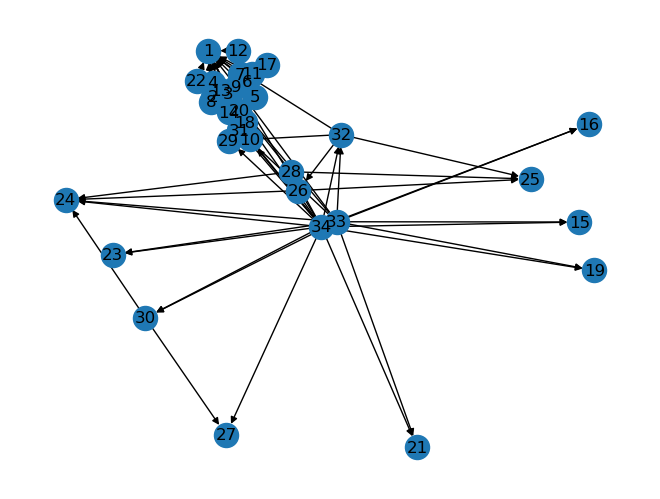

In [95]:
import matplotlib.pyplot as plt
import networkx as nx

# Karate Network Dataset (https://en.wikipedia.org/wiki/Zachary%27s_karate_club)

# ノードのIDを列挙
karate_nodes = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]

# エッジをIDのペアで表現． 
# 例) [2, 1]: ノード２からノード1へエッジがある．
karate_edges = [
    [2, 1], 
    [3, 1], [3, 2], 
    [4, 1], [4, 2], [4, 3], 
    [5, 1], 
    [6, 1], 
    [7, 1], [7, 5], [7, 6], 
    [8, 1], [8, 2], [8, 3], [8, 4], 
    [9, 1], [9, 3], 
    [10, 3], 
    [11, 1], [11, 5], [11, 6], 
    [12, 1], 
    [13, 1], [13, 4], 
    [14, 1], [14, 2], [14, 3], [14, 4], 
    [17, 6], [17, 7], 
    [18, 1], [18, 2], 
    [20, 1], [20, 2], 
    [22, 1], [22, 2], 
    [26, 24], [26, 25], 
    [28, 3], [28, 24], [28, 25], 
    [29, 3], 
    [30, 24], [30, 27], 
    [31, 2], [31, 9], 
    [32, 1], [32, 25], [32, 26], [32, 29], 
    [33, 3], [33, 9], [33, 15], [33, 16], [33, 19], [33, 21], [33, 23], [33, 24], [33, 30], [33, 31], [33, 32], 
    [34, 9], [34, 10], [34, 14], [34, 15], [34, 16], [34, 19], [34, 20], [34, 21], [34, 23], [34, 24], [34, 27], [34, 28], [34, 29], [34, 30], [34, 31], [34, 32], [34, 33], 
]

# 有向グラフの定義
graph = nx.DiGraph()
labels = {}

# ノードを追加
for node in karate_nodes:
    graph.add_node(node)    
    labels[node] = node

# エッジを追加
for start_node, end_node in karate_edges:
    # add edges
    graph.add_edge(start_node, end_node)

# グラフを描画
pos = nx.spring_layout(graph) # ノードの位置をバネモデルによって決定
nx.draw(graph, pos) # posで指定された位置へグラフを描画
nx.draw_networkx_labels(graph, pos, labels, font_size=12) # ノードのラベルを描画
plt.show()

### HITS アルゴリズム

In [100]:
### リスト4 ###

import networkx as nx

# 有向グラフの作成
G = nx.DiGraph()
G.add_edges_from([
    ('A', 'B'), ('A', 'C'),
    ('B', 'C'),
    ('C', 'A'),
    ('D', 'C')
])

# HITSアルゴリズムの計算
hubs, authorities = nx.hits(G)

# 指定した順番（A, B, C, D）で表示
nodes_order = ['A', 'B', 'C', 'D']

print("Hub Scores:")
for node in nodes_order:
    print(f"  {node}: {hubs[node]:.4f}")

print("\nAuthority Scores:")
for node in nodes_order:
    print(f"  {node}: {authorities[node]:.4f}")

Hub Scores:
  A: 0.4142
  B: 0.2929
  C: 0.0000
  D: 0.2929

Authority Scores:
  A: 0.0000
  B: 0.2929
  C: 0.7071
  D: 0.0000


### PageRankアルゴリズム

PageRank scores (アルファベット順):
Page A: 0.3725
Page B: 0.1958
Page C: 0.3942
Page D: 0.0375


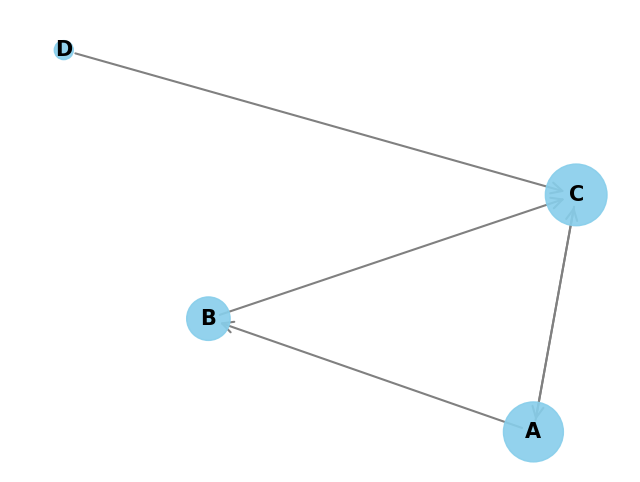

In [109]:
import networkx as nx
import matplotlib.pyplot as plt

# 有向グラフの作成（アルファベットで定義）
G = nx.DiGraph()
edges = [('A', 'B'), ('A', 'C'), 
         ('B', 'C'), 
         ('C', 'A'), 
         ('D', 'C')]
G.add_edges_from(edges)

# PageRankの計算
pagerank = nx.pagerank(G, alpha=0.85)

# 結果をアルファベット順に表示
print("PageRank scores (アルファベット順):")
for node in sorted(G.nodes()):
    print(f"Page {node}: {pagerank[node]:.4f}")

# 可視化
plt.figure(figsize=(8, 6))

# レイアウト（配置）の決定
pos = nx.spring_layout(G, seed=42) 
#pos = nx.spring_layout(G) 

# ノードの大きさをPageRankスコアに比例させる (スコア * 5000倍)
node_sizes = [pagerank[node] * 5000 for node in G.nodes()]

# 描画
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=15, font_family='sans-serif', font_weight='bold')
nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='gray', width=1.5)

plt.axis('off') # 座標軸を非表示
plt.show()